# Анализ и предобработка данных N-BaIoT

**Датасет:** сетевой трафик с 9 IoT-устройств, заражённых ботнетами **Mirai** и **Gafgyt**.  
**Признаки:** 115 статистик сетевых потоков (MI_dir, H, HH, HH_jit, HpHp) × 5 Lambda.  
**Цель:** EDA, предобработка и подготовка к ML.

## Импорт библиотек и настройка окружения

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, gc, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DEVICE_NAMES = {
    1: 'Danmini Doorbell', 2: 'Ecobee Thermostat', 3: 'Ennio Doorbell',
    4: 'Philips Baby Monitor', 5: 'Provision PT-737E', 6: 'Provision PT-838',
    7: 'Samsung Webcam', 8: 'SimpleHome XCS7-1002', 9: 'SimpleHome XCS7-1003'
}

## 1. Загрузка всех CSV-файлов из папки data/

Каждый файл имеет формат `<device_id>.<botnet>.<attack>.csv`. Парсим имя файла, извлекаем метаданные (устройство, ботнет, метка класса) и объединяем всё в один DataFrame. Используем `float32` для экономии памяти.

In [2]:
DATA_DIR = 'data'
csv_files = sorted([f for f in glob.glob(os.path.join(DATA_DIR, '[0-9]*.csv')) if 'Zone' not in f])

def parse_filename(filepath):
    parts = os.path.basename(filepath).replace('.csv', '').split('.')
    dev = int(parts[0])
    if parts[1] == 'benign':
        return dev, 'benign', 'benign'
    return dev, parts[1], f"{parts[1]}.{parts[2]}"

dfs = []
for f in csv_files:
    dev, botnet, label = parse_filename(f)
    tmp = pd.read_csv(f, dtype=np.float32)
    tmp['device_id'] = np.int8(dev)
    tmp['botnet'] = botnet
    tmp['label'] = label
    tmp['is_malicious'] = np.int8(0 if botnet == 'benign' else 1)
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)
del dfs; gc.collect()

for col in ['botnet', 'label']:
    df[col] = df[col].astype('category')

meta_cols = ['device_id', 'botnet', 'label', 'is_malicious']
feature_cols = [c for c in df.columns if c not in meta_cols]

print(f"Загружено: {len(df):,} строк × {len(feature_cols)} признаков")
print(f"Память: {df.memory_usage(deep=True).sum() / 1024**3:.2f} ГБ")
print(f"\nРаспределение по классам:")
print(df['label'].value_counts().sort_index())

Загружено: 7,062,606 строк × 115 признаков
Память: 3.05 ГБ

Распределение по классам:
label
benign             555932
gafgyt.combo       515156
gafgyt.junk        261789
gafgyt.scan        255111
gafgyt.tcp         859850
gafgyt.udp         946366
mirai.ack          643821
mirai.scan         537979
mirai.syn          733299
mirai.udp         1229999
mirai.udpplain     523304
Name: count, dtype: int64


## 2. Очистка данных

Проверяем наличие пропусков и бесконечных значений. Если есть — заменяем inf на NaN и заполняем медианой столбца. Обработка идёт поколоночно для экономии памяти.

In [3]:
n_missing, n_inf = 0, 0
for col in feature_cols:
    m = np.isinf(df[col])
    if m.any():
        n_inf += m.sum(); df.loc[m, col] = np.nan
    n = df[col].isnull().sum()
    if n > 0:
        n_missing += n; df[col].fillna(df[col].median(), inplace=True)

print(f"Пропуски: {n_missing} | Inf: {n_inf}")
print(f"Типы данных: все {len(feature_cols)} признаков — float32")
print(f"Размер после очистки: {df.shape[0]:,} × {len(feature_cols)}")

Пропуски: 0 | Inf: 0
Типы данных: все 115 признаков — float32
Размер после очистки: 7,062,606 × 115


## 3. Разведочный анализ данных (EDA)

Для визуализации берём стратифицированную подвыборку ~40K строк — полный датасет слишком велик для построения графиков.

### 3.1 Формирование стратифицированной подвыборки для визуализации

In [4]:
sample_dfs = []
for lab in df['label'].unique():
    g = df[df['label'] == lab]
    sample_dfs.append(g.sample(min(len(g), max(300, 40000 * len(g) // len(df))), random_state=42))
df_sample = pd.concat(sample_dfs, ignore_index=True)
del sample_dfs; gc.collect()
print(f"Подвыборка: {len(df_sample):,} строк")

Подвыборка: 39,993 строк


### 3.2 Тепловая карта: количество записей по устройствам и типам трафика

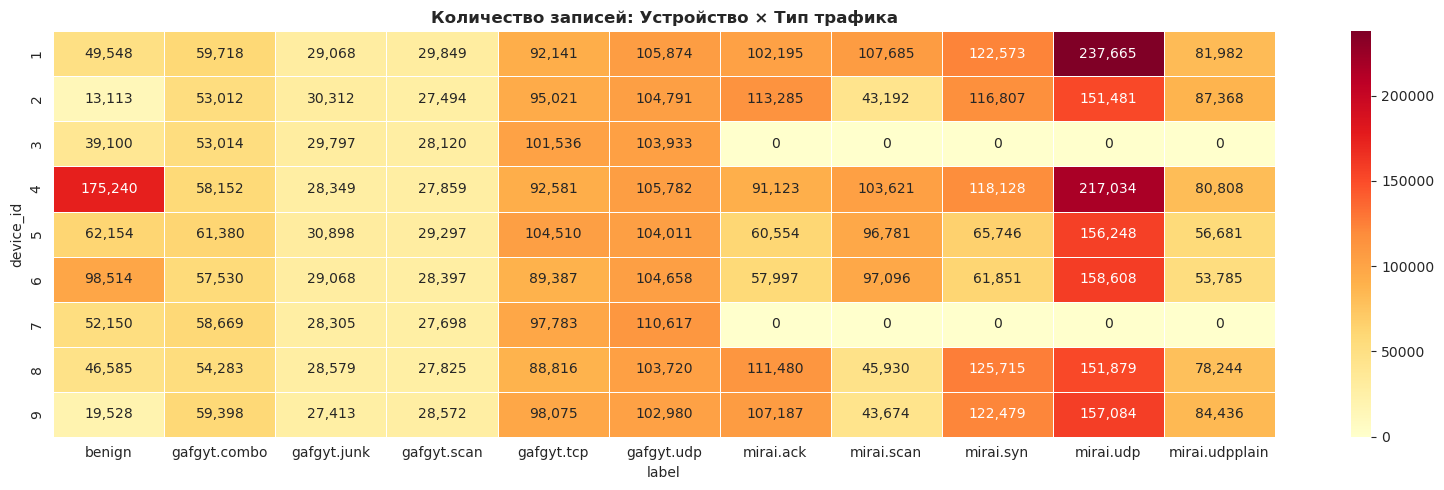

In [5]:
pivot = df.groupby(['device_id', 'label']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, annot=True, fmt=',', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Количество записей: Устройство × Тип трафика', fontweight='bold')
plt.tight_layout(); plt.show()

### 3.3 Сравнение распределений признаков между benign, Gafgyt и Mirai

KDE-графики для признаков группы L1_mean показывают, насколько отличаются распределения нормального и вредоносного трафика.

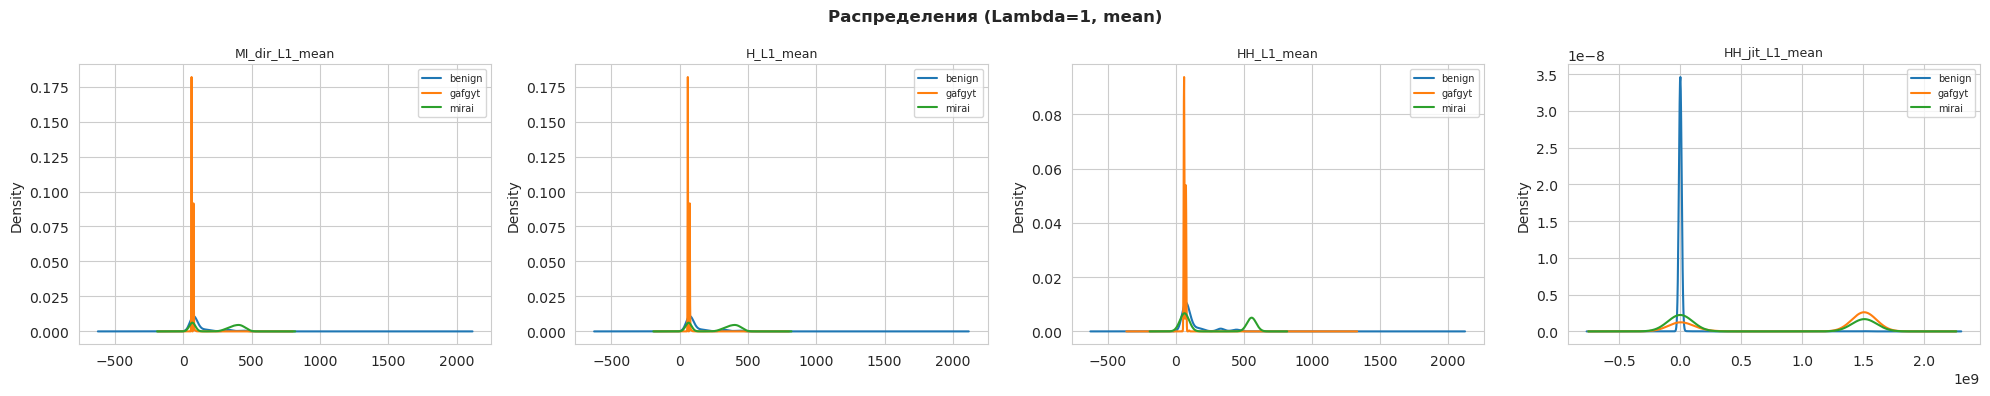

In [6]:
plot_feats = [c for c in feature_cols if 'L1_mean' in c][:4]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for idx, feat in enumerate(plot_feats):
    for bot in ['benign', 'gafgyt', 'mirai']:
        s = df_sample[df_sample['botnet'] == bot][feat].dropna()
        if len(s) > 10 and s.std() > 0:
            s.plot.kde(ax=axes[idx], label=bot, linewidth=1.5)
    axes[idx].set_title(feat, fontsize=9); axes[idx].legend(fontsize=7)
fig.suptitle('Распределения (Lambda=1, mean)', fontweight='bold')
plt.tight_layout(); plt.show()

### 3.4 Корреляционная матрица Пирсона и подсчёт избыточных пар

Строим матрицу корреляций для всех 115 признаков. Подсчитываем количество пар с |r| > 0.95 — это признаки-дубликаты, которые можно удалить при отборе.

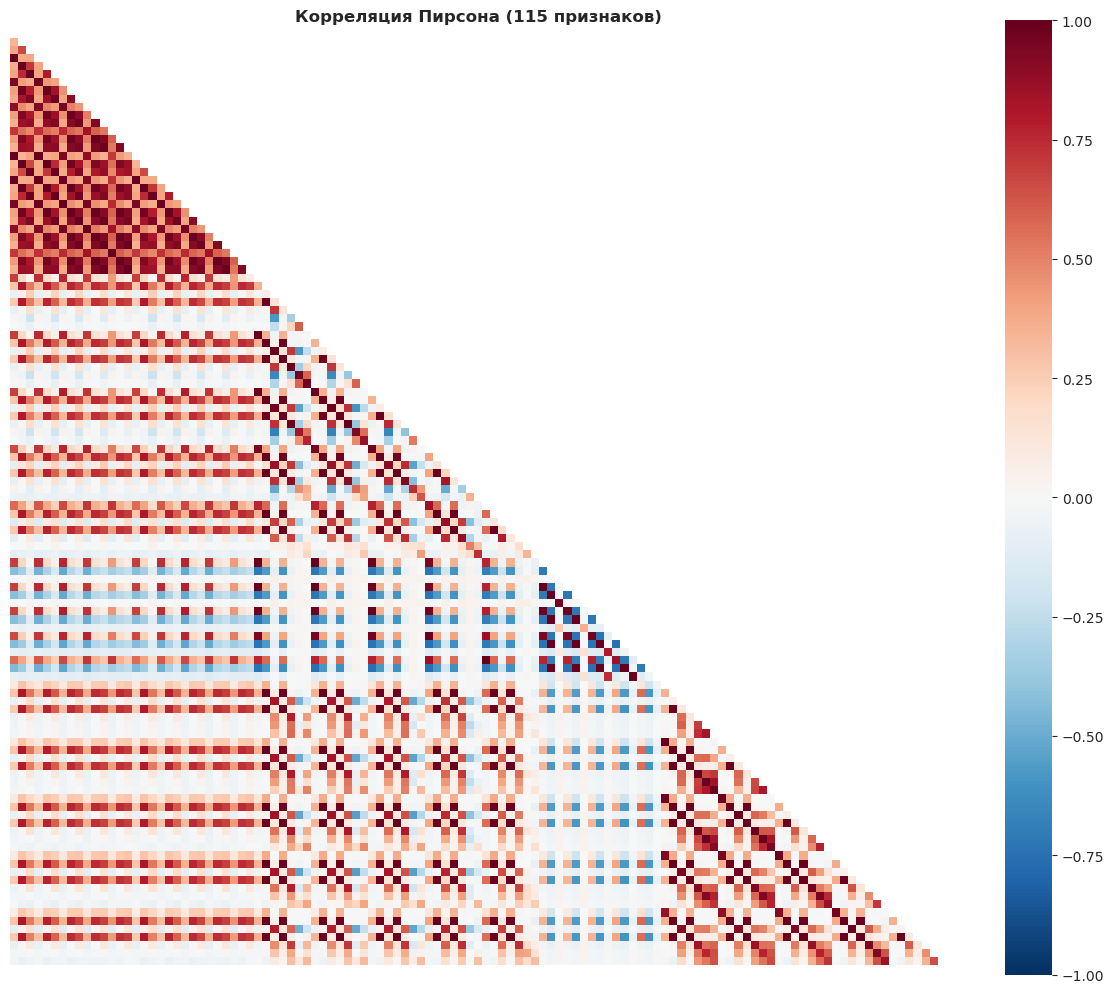

Пар с |r| > 0.95: 330 — высокая избыточность признаков


In [7]:
corr = df_sample[feature_cols].corr(method='pearson')
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, xticklabels=False, yticklabels=False, ax=ax)
ax.set_title('Корреляция Пирсона (115 признаков)', fontweight='bold')
plt.tight_layout(); plt.show()

upper = corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1))
high_corr = [(r, c) for c in upper.columns for r in upper.index
             if pd.notna(upper.loc[r, c]) and abs(upper.loc[r, c]) > 0.95]
print(f"Пар с |r| > 0.95: {len(high_corr)} — высокая избыточность признаков")

### 3.5 Обнаружение выбросов методом IQR

Для каждого признака определяем процент значений, выходящих за пределы 1.5×IQR. Высокий процент выбросов ожидаем — вредоносный трафик по природе отличается от нормального.

In [8]:
outlier_pct = {}
for col in feature_cols:
    Q1, Q3 = df_sample[col].quantile(0.25), df_sample[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_pct[col] = ((df_sample[col] < Q1 - 1.5*IQR) | (df_sample[col] > Q3 + 1.5*IQR)).mean() * 100

outlier_s = pd.Series(outlier_pct).sort_values(ascending=False)
print(f"Признаков с >10% выбросов: {(outlier_s > 10).sum()} из {len(feature_cols)}")
print(f"Топ-5: {outlier_s.head().round(1).to_dict()}")

Признаков с >10% выбросов: 52 из 115
Топ-5: {'HH_L3_radius': 24.4, 'HH_L0.1_magnitude': 24.1, 'HH_L3_magnitude': 24.1, 'HH_L1_magnitude': 24.1, 'HH_L5_magnitude': 24.1}


## 4. Отбор признаков с помощью RandomForest

Обучаем RandomForest на подвыборке (benign vs malicious) и ранжируем признаки по важности. Отбираем Топ-25 для дальнейшего использования.

Accuracy RF (train): 1.0000

Топ-15 признаков:
   1. HH_jit_L0.01_mean                   0.1410
   2. HH_L0.01_radius                     0.0701
   3. HH_L0.01_covariance                 0.0580
   4. HH_L0.01_pcc                        0.0559
   5. HpHp_L0.1_std                       0.0495
   6. HpHp_L0.01_radius                   0.0495
   7. HpHp_L0.01_std                      0.0488
   8. HpHp_L0.1_radius                    0.0481
   9. HpHp_L0.01_weight                   0.0346
  10. HH_L0.1_pcc                         0.0225
  11. MI_dir_L0.01_weight                 0.0223
  12. HH_L0.1_radius                      0.0221
  13. H_L0.01_weight                      0.0221
  14. HpHp_L0.1_weight                    0.0199
  15. HpHp_L1_radius                      0.0192


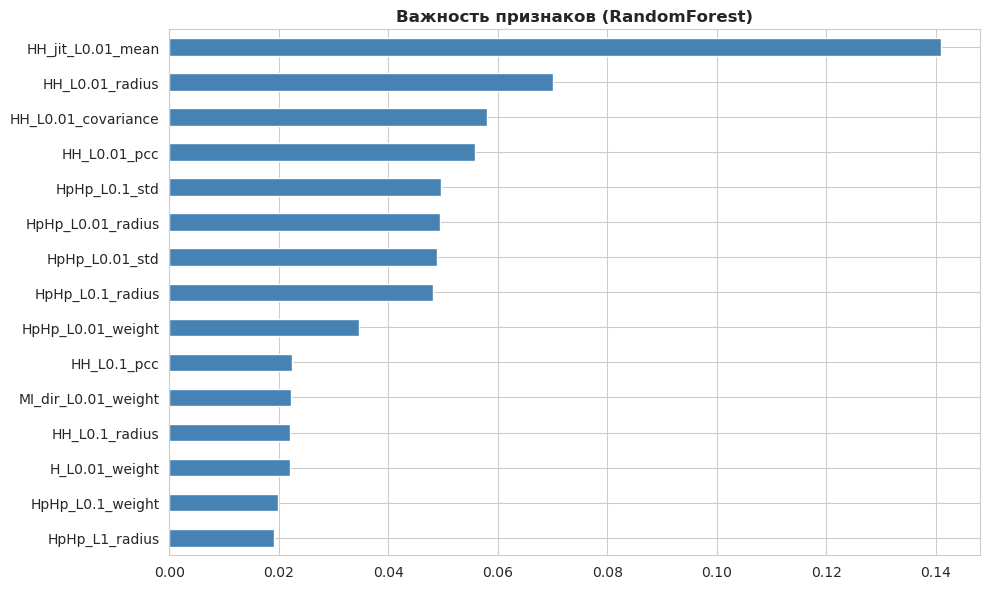

15213

In [9]:
scaler = StandardScaler()
X_s = scaler.fit_transform(df_sample[feature_cols]).astype(np.float32)
y_s = df_sample['is_malicious'].values

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_s, y_s)
importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

print(f"Accuracy RF (train): {rf.score(X_s, y_s):.4f}")
print(f"\nТоп-15 признаков:")
for i, (feat, val) in enumerate(importance.head(15).items()):
    print(f"  {i+1:2d}. {feat:35s} {val:.4f}")

top_features = importance.head(25).index.tolist()

fig, ax = plt.subplots(figsize=(10, 6))
importance.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Важность признаков (RandomForest)', fontweight='bold')
plt.tight_layout(); plt.show()

del X_s; gc.collect()

## 5. Визуализация в пространстве главных компонент (PCA)

Проецируем данные на первые 2 главные компоненты, чтобы оценить разделимость классов. Также определяем, сколько компонент нужно для объяснения 95% дисперсии.

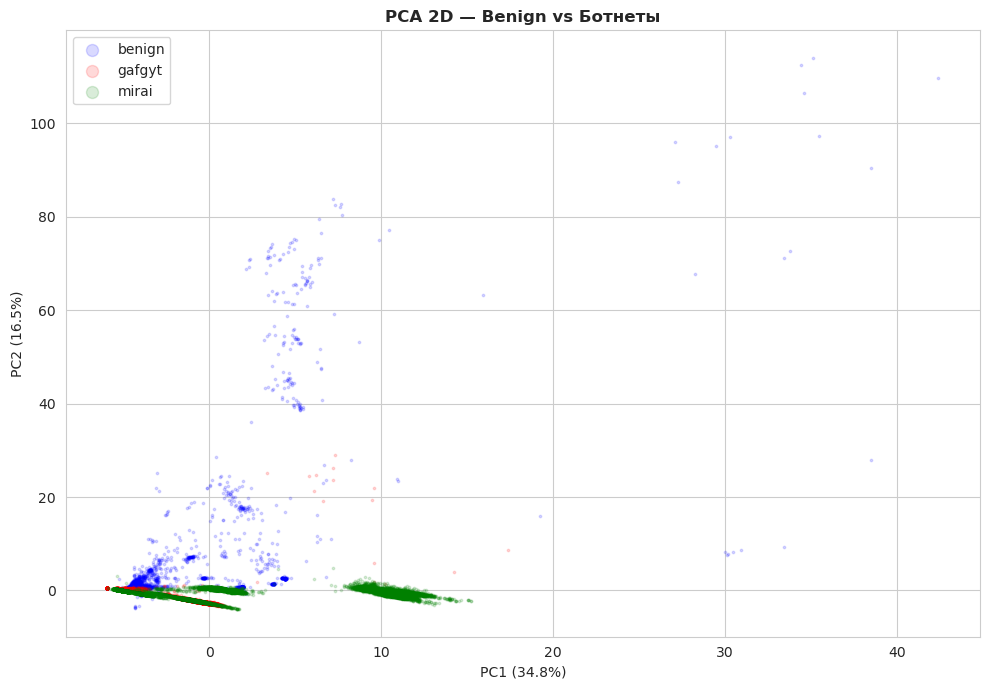

Для 95% дисперсии нужно 17 компонент из 115


4584

In [10]:
X_scaled = StandardScaler().fit_transform(df_sample[feature_cols]).astype(np.float32)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
del X_scaled

fig, ax = plt.subplots(figsize=(10, 7))
for bot, color in [('benign', 'blue'), ('gafgyt', 'red'), ('mirai', 'green')]:
    m = df_sample['botnet'] == bot
    ax.scatter(X_pca[m, 0], X_pca[m, 1], c=color, alpha=0.15, s=3, label=bot)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA 2D — Benign vs Ботнеты', fontweight='bold')
ax.legend(markerscale=5)
plt.tight_layout(); plt.show()

pca_full = PCA(random_state=42).fit(StandardScaler().fit_transform(df_sample[feature_cols]))
n95 = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.95) + 1
print(f"Для 95% дисперсии нужно {n95} компонент из {len(feature_cols)}")
del pca_full; gc.collect()

## 6. Выводы

1. **Датасет:** ~7M записей, 115 признаков, 9 устройств, 11 классов (benign + 5 Gafgyt + 5 Mirai). Устройства 3 и 7 — только Gafgyt.
2. **Качество:** пропусков и inf нет, данные чистые.
3. **Корреляция:** высокая избыточность — много пар с |r| > 0.95. Нужен отбор признаков.
4. **PCA:** классы хорошо разделимы уже в 2D. Для 95% дисперсии достаточно ~20 компонент.
5. **Важные признаки:** HH_jit (джиттер), HpHp (port-level), H (host-level) при коротких Lambda.
6. **Дисбаланс:** malicious >> benign. Соотношение классов нужно учитывать при обучении моделей.